# 03 — Exploratory Data Analysis

Runs `src/eda.py` to produce the core business-question-driven charts.

All figures are saved to `outputs/figures/` for use in the README and
Power BI dashboard.


In [1]:

result = run_script("eda.py")

if result.returncode != 0:
    print("EDA failed.")


  saved 01_age_distribution.png
  saved 02_customer_growth.png
  saved 03_monthly_revenue_trend.png
  saved 04_plan_distribution.png
  saved 05_acquisition_channel_mix.png
  saved 06_churn_by_acquisition_channel.png
  saved 07_churn_by_plan.png
  saved 08_churn_by_billing_cycle.png
  saved 09_monthly_churn_trend.png
  saved 10_engagement_active_vs_churned.png
  saved 11_churn_by_support_tickets.png
  saved 12_churn_by_satisfaction.png
  saved 13_tenure_at_churn.png
  saved 14_revenue_by_region.png
  saved 15_churn_by_discount.png
  saved 16_feature_usage_active_vs_churned.png
  saved 17_churn_by_age_group.png

EDA complete. 17 figures saved to C:\Users\ayuu1\Desktop\customer-retention-intelligence\customer-retention-intelligence\outputs\figures



## Load processed data for inline analysis

In [2]:

import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

PROCESSED = ROOT / "data" / "processed"

customers = pd.read_csv(
    PROCESSED / "customers.csv",
    parse_dates=["signup_date"]
)

subscriptions = pd.read_csv(
    PROCESSED / "subscriptions.csv",
    parse_dates=[
        "start_date",
        "end_date",
        "cancellation_date"
    ]
)

transactions = pd.read_csv(
    PROCESSED / "transactions.csv",
    parse_dates=["transaction_date"]
)

plans = pd.read_csv(
    PROCESSED / "plans.csv"
)

latest_sub = (
    subscriptions
    .sort_values("start_date")
    .groupby("customer_id")
    .last()
    .reset_index()
)

cust = customers.merge(
    latest_sub[
        [
            "customer_id",
            "plan_id",
            "billing_cycle",
            "subscription_status"
        ]
    ],
    on="customer_id"
)

cust = cust.merge(
    plans[
        [
            "plan_id",
            "plan_name"
        ]
    ],
    on="plan_id"
)

print(
    f"customers: {len(customers):,} | "
    f"subscriptions: {len(subscriptions):,} | "
    f"transactions: {len(transactions):,}"
)

print(
    f"Overall churn rate: "
    f"{(cust['subscription_status'] == 'Cancelled').mean():.2%}"
)


customers: 52,000 | subscriptions: 52,563 | transactions: 393,498
Overall churn rate: 20.64%


### Chart: Age distribution

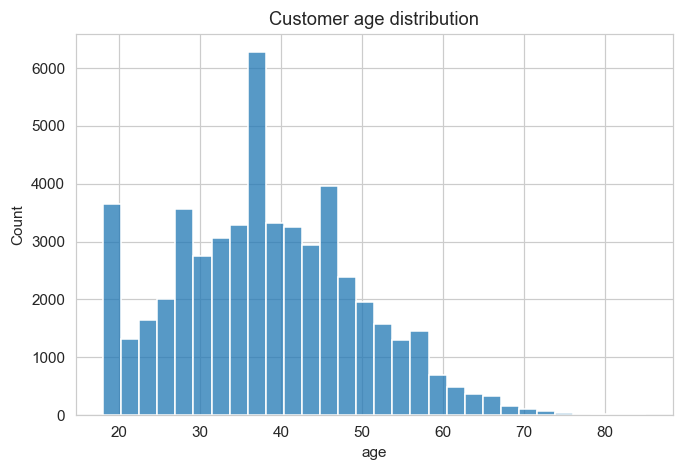

In [3]:

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.histplot(
    customers["age"],
    bins=30,
    ax=ax
)

ax.set_title(
    "Customer age distribution"
)

plt.show()


**Takeaway:** The customer base skews toward working-age adults,
consistent with a mainstream consumer SaaS product.

### Chart: Churn rate by plan

plan_name
Basic         24.26
Standard      20.59
Premium       18.37
Enterprise    14.82
Name: subscription_status, dtype: float64


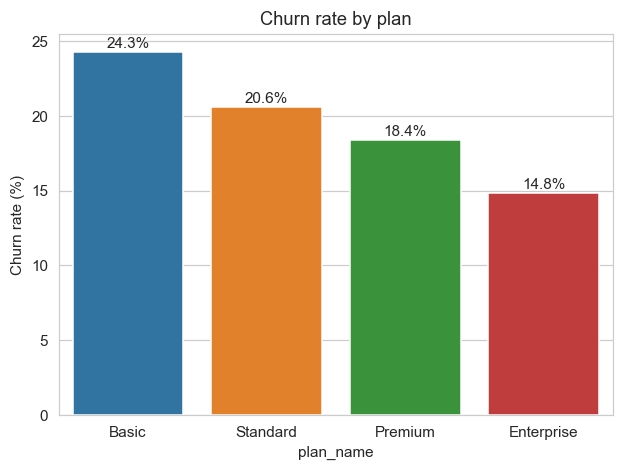

In [4]:

churn_by_plan = (
    cust
    .groupby("plan_name")["subscription_status"]
    .apply(
        lambda s:
        (s == "Cancelled").mean() * 100
    )
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(
    figsize=(6.5, 4.5)
)

sns.barplot(
    x=churn_by_plan.index,
    y=churn_by_plan.values,
    hue=churn_by_plan.index,
    legend=False,
    ax=ax
)

ax.set_ylabel(
    "Churn rate (%)"
)

ax.set_title(
    "Churn rate by plan"
)

for i, v in enumerate(
    churn_by_plan.values
):
    ax.text(
        i,
        v + 0.3,
        f"{v:.1f}%",
        ha="center"
    )

plt.show()

print(
    churn_by_plan.round(2)
)


**Takeaway:** Entry-level plans churn noticeably more than
premium/enterprise plans.

### Chart: Monthly revenue trend

Total revenue across the observation window: $9,908,446.17


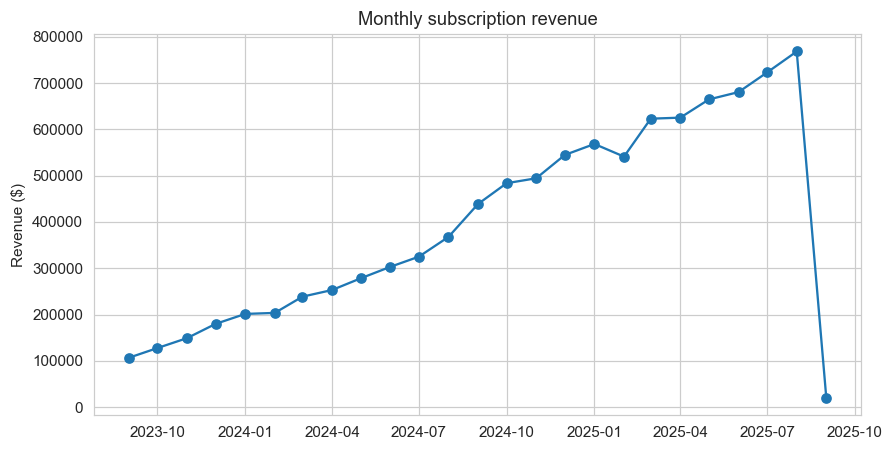

In [5]:

rev = transactions[
    (
        transactions["transaction_type"]
        == "Subscription Charge"
    )
    &
    (
        transactions["payment_status"]
        == "Success"
    )
]

monthly_rev = (
    rev
    .set_index("transaction_date")
    .resample("MS")["amount"]
    .sum()
)

fig, ax = plt.subplots(
    figsize=(9, 4.5)
)

ax.plot(
    monthly_rev.index,
    monthly_rev.values,
    marker="o"
)

ax.set_title(
    "Monthly subscription revenue"
)

ax.set_ylabel(
    "Revenue ($)"
)

plt.show()

print(
    f"Total revenue across the observation window: "
    f"${rev['amount'].sum():,.2f}"
)


**Takeaway:** Revenue trends upward with the growing customer base,
although month-to-month growth is uneven.

### Chart: Churn by billing cycle

billing_cycle
Annual     14.61
Monthly    23.49
Name: subscription_status, dtype: float64


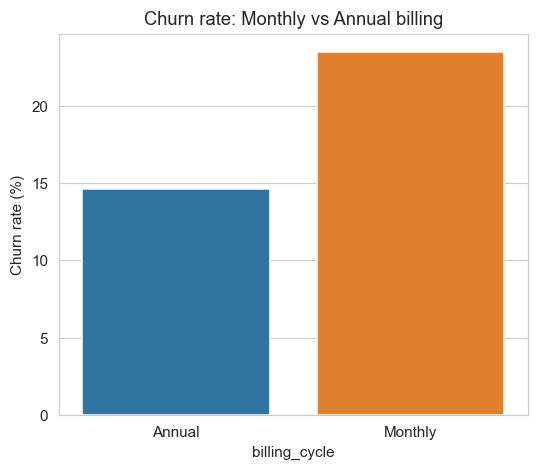

In [6]:

churn_by_billing = (
    cust
    .groupby("billing_cycle")["subscription_status"]
    .apply(
        lambda s:
        (s == "Cancelled").mean() * 100
    )
)

fig, ax = plt.subplots(
    figsize=(5.5, 4.5)
)

sns.barplot(
    x=churn_by_billing.index,
    y=churn_by_billing.values,
    hue=churn_by_billing.index,
    legend=False,
    ax=ax
)

ax.set_ylabel(
    "Churn rate (%)"
)

ax.set_title(
    "Churn rate: Monthly vs Annual billing"
)

plt.show()

print(
    churn_by_billing.round(2)
)


**Takeaway:** Monthly-billed customers churn at a meaningfully
higher rate than annual subscribers.

All 18 EDA figures, including the cohort heatmap, are saved under
`outputs/figures/`.